# Arabic Text Generation using NanoGPT
**CSDS4102 – Natural Language Processing Mini Project | Semester 2 2025-2026**

**Task:** Text Generation  
**Dataset:** [ArabicText-Large](https://huggingface.co/datasets/Jr23xd23/ArabicText-Large) – 743K Arabic articles (244M words)  
**DL Model:** NanoGPT trained **from scratch** on Arabic text  
**ML Model:** N-gram Language Model (bigram + trigram with Laplace smoothing)

In [10]:
! pip install datasets torch scikit-learn matplotlib seaborn streamlit

In [ ]:
import json, random, time
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from collections import defaultdict

import torch

matplotlib.rcParams['font.family'] = 'DejaVu Sans'
plt.style.use('seaborn-v0_8-whitegrid')

SEED =42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


---
## Section 1 – Task & Dataset Selection

**Title:** Arabic Text Generation using a NanoGPT Character-Level Language Model

**NLP Task:** Text Generation (causal/autoregressive language modelling)

**Justification:**  
Arabic is morphologically rich and right-to-left, making text generation challenging and under-studied. Autoregressive language modelling provides a strong generative backbone for downstream tasks (summarisation, dialogue, translation). NanoGPT, trained from scratch on the ArabicText-Large corpus, learns Arabic syntax and morphology without any pretrained weights.

**Dataset:**  
- Source: HuggingFace – `Jr23xd23/ArabicText-Large`  
- Size: 743,288 articles · 244M words · 2.8 GB  
- Fields: `id`, `title`, `text`, `url`, `hash`, `metadata`  
- We stream 50,000 articles (~90M characters) to keep training feasible on standard hardware.

In [ ]:
"""
Data preparation for Arabic Text Generation.
Downloads ArabicText-Large from HuggingFace, preprocesses, tokenizes,
and saves binary files for nanoGPT-style training.
"""

import os
import re
import pickle
import random
import numpy as np
from collections import Counter

# ── Arabic preprocessing ──────────────────────────────────────────────────

DIACRITICS  = re.compile(
    u'[ؐ-ؚ'  # Arabic annotation signs U+0610-U+061A
    u'ً-ٟ'  # Arabic tashkeel (fatha, damma, kasra, shadda, sukun, tanwin, ...)
    u'ٰ'  # Superscript alef
    u'ۖ-ۜ۟-ۭ]'  # Extended Arabic marks
)
NON_ARABIC  = re.compile(r'[^؀-ۿ\s\n\.\،\؟\!\:\-]')
URL_PAT     = re.compile(r'http\S+|www\.\S+')
HTML_PAT    = re.compile(r'<[^>]+>')
MULTI_SPACE = re.compile(r'[ \t]+')

ARABIC_NORM = str.maketrans({
    'آ': 'ا', 'أ': 'ا', 'إ': 'ا', 'ٱ': 'ا',
    'ة': 'ه',
    'ى': 'ي',
})

NOISE_DIACRITICS = ['َ', 'ُ', 'ِ', 'ْ', 'ّ']


def remove_urls(text):        return URL_PAT.sub(' ', text)
def remove_html(text):        return HTML_PAT.sub(' ', text)
def remove_diacritics(text):  return DIACRITICS.sub('', text)
def normalize_arabic(text):   return text.translate(ARABIC_NORM)
def remove_non_arabic(text):  return NON_ARABIC.sub(' ', text)
def normalize_whitespace(text):
    text = MULTI_SPACE.sub(' ', text)
    # collapse more than 2 consecutive newlines
    text = re.sub(r'\n{3,}', '\n\n', text)
    return text.strip()


def preprocess_text(text: str) -> str:
    """Full 6-step preprocessing pipeline."""
    text = remove_urls(text)
    text = remove_html(text)
    text = remove_diacritics(text)
    text = normalize_arabic(text)
    text = remove_non_arabic(text)
    text = normalize_whitespace(text)
    return text


def inject_noise(text: str, noise_ratio: float = 0.02) -> str:
    """Insert random Arabic diacritics to simulate a noisy corpus."""
    chars = list(text)
    n_noise = max(1, int(len(chars) * noise_ratio))
    for _ in range(n_noise):
        pos = random.randint(0, len(chars) - 1)
        if chars[pos] not in (' ', '\n'):
            chars.insert(pos + 1, random.choice(NOISE_DIACRITICS))
    return ''.join(chars)


# ── Character-level tokenizer ─────────────────────────────────────────────

class ArabicCharTokenizer:
    SPECIAL = ['<PAD>', '<UNK>', '<BOS>', '<EOS>']

    def __init__(self):
        self.char2idx = {}
        self.idx2char = {}
        self.vocab_size = 0

    def build_vocab(self, texts, max_vocab=512):
        counter = Counter()
        for text in texts:
            counter.update(text)
        common = [ch for ch, _ in counter.most_common(max_vocab - len(self.SPECIAL))]
        vocab = self.SPECIAL + common
        self.char2idx = {ch: i for i, ch in enumerate(vocab)}
        self.idx2char = {i: ch for i, ch in enumerate(vocab)}
        self.vocab_size = len(vocab)
        print(f"Vocabulary: {self.vocab_size} characters")
        return self

    def encode(self, text, max_len=None):
        unk = self.char2idx['<UNK>']
        ids = [self.char2idx.get(ch, unk) for ch in text]
        if max_len is not None:
            ids = ids[:max_len]
            ids += [self.char2idx['<PAD>']] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        specials = set(self.SPECIAL)
        return ''.join(
            self.idx2char.get(i, '')
            for i in ids
            if self.idx2char.get(i, '') not in specials
        )

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump({
                'char2idx': self.char2idx,
                'idx2char': self.idx2char,
                'vocab_size': self.vocab_size,
            }, f)

    @classmethod
    def load(cls, path):
        tok = cls()
        with open(path, 'rb') as f:
            d = pickle.load(f)
        tok.char2idx   = d['char2idx']
        tok.idx2char   = d['idx2char']
        tok.vocab_size = d['vocab_size']
        return tok


# ── BPE tokenizer (second feature representation) ─────────────────────────

class SimpleBPETokenizer:
    """
    Minimal byte-pair encoding tokenizer built from scratch.
    Used as the second feature representation for comparison.
    """

    def __init__(self, vocab_size=1000):
        self.target_vocab_size = vocab_size
        self.merges = {}       # (pair) -> merged_token
        self.vocab  = {}       # token -> id
        self.id2tok = {}

    def _get_pairs(self, word_freqs):
        pairs = Counter()
        for word, freq in word_freqs.items():
            symbols = word.split()
            for i in range(len(symbols) - 1):
                pairs[(symbols[i], symbols[i + 1])] += freq
        return pairs

    def _merge_pair(self, pair, word_freqs):
        new_word_freqs = {}
        bigram = ' '.join(pair)
        replacement = ''.join(pair)
        for word, freq in word_freqs.items():
            new_word = word.replace(bigram, replacement)
            new_word_freqs[new_word] = freq
        return new_word_freqs

    def fit(self, texts, num_merges=200):
        # Initialize: every character is a token, words split into chars
        word_freqs = Counter()
        for text in texts:
            for word in text.split():
                word_freqs[' '.join(list(word)) + ' </w>'] += 1

        # Build initial vocab from characters
        all_tokens = set()
        for word in word_freqs:
            all_tokens.update(word.split())
        self.vocab = {tok: i for i, tok in enumerate(sorted(all_tokens))}

        # BPE merges
        for _ in range(num_merges):
            pairs = self._get_pairs(word_freqs)
            if not pairs:
                break
            best = pairs.most_common(1)[0][0]
            word_freqs = self._merge_pair(best, word_freqs)
            self.merges[best] = ''.join(best)
            merged = ''.join(best)
            if merged not in self.vocab:
                self.vocab[merged] = len(self.vocab)

        self.id2tok = {v: k for k, v in self.vocab.items()}
        print(f"BPE vocab size: {len(self.vocab)}")
        return self

    def _apply_merges(self, word_chars):
        """Apply BPE merges to a list of character tokens for one word."""
        tokens = word_chars
        while len(tokens) > 1:
            # find the highest-priority (earliest) merge among adjacent pairs
            best_idx = None
            best_rank = len(self.merges)
            pairs_list = list(self.merges.keys())
            for i in range(len(tokens) - 1):
                pair = (tokens[i], tokens[i + 1])
                if pair in self.merges:
                    rank = pairs_list.index(pair)
                    if rank < best_rank:
                        best_rank = rank
                        best_idx = i
            if best_idx is None:
                break
            merged = self.merges[(tokens[best_idx], tokens[best_idx + 1])]
            tokens = tokens[:best_idx] + [merged] + tokens[best_idx + 2:]
        return tokens

    def encode(self, text, max_len=None):
        unk_id = 0
        merge_rank = {pair: i for i, pair in enumerate(self.merges.keys())}
        word_cache = {}
        ids = []
        for word in text.split():
            if word in word_cache:
                ids.extend(word_cache[word])
                continue
            tokens = list(word) + ['</w>']
            while len(tokens) > 1:
                best_idx, best_rank = None, len(merge_rank)
                for i in range(len(tokens) - 1):
                    pair = (tokens[i], tokens[i + 1])
                    rank = merge_rank.get(pair, len(merge_rank))
                    if rank < best_rank:
                        best_rank, best_idx = rank, i
                if best_idx is None:
                    break
                merged = self.merges[(tokens[best_idx], tokens[best_idx + 1])]
                tokens = tokens[:best_idx] + [merged] + tokens[best_idx + 2:]
            word_ids = [self.vocab.get(tok, unk_id) for tok in tokens]
            word_cache[word] = word_ids
            ids.extend(word_ids)
        if max_len is not None:
            ids = ids[:max_len]
            ids += [0] * (max_len - len(ids))
        return ids

    def decode(self, ids):
        tokens = [self.id2tok.get(i, '') for i in ids]
        text = ''.join(tokens).replace('</w>', ' ')
        return text.strip()

    def save(self, path):
        with open(path, 'wb') as f:
            pickle.dump({'merges': self.merges, 'vocab': self.vocab,
                         'id2tok': self.id2tok,
                         'target_vocab_size': self.target_vocab_size}, f)

    @classmethod
    def load(cls, path):
        with open(path, 'rb') as f:
            d = pickle.load(f)
        tok = cls(d['target_vocab_size'])
        tok.merges = d['merges']
        tok.vocab  = d['vocab']
        tok.id2tok = d['id2tok']
        return tok


# ── Main preparation ──────────────────────────────────────────────────────

def prepare_data(
    sample_size: int = 50000,
    val_ratio:   float = 0.1,
    out_dir:     str   = 'data',
    seed:        int   = 42,
):
    random.seed(seed)
    np.random.seed(seed)
    os.makedirs(out_dir, exist_ok=True)s

    print("Loading ArabicText-Large from HuggingFace (streaming)...")
    from datasets import load_dataset
    dataset = load_dataset("Jr23xd23/ArabicText-Large", split='train', streaming=True)

    raw_texts = []
    for article in dataset:
        text = article.get('text', '') or ''
        if len(text) > 200:
            raw_texts.append(text)
        if len(raw_texts) >= sample_size:
            break
    print(f"Collected {len(raw_texts)} articles")

    # Save representative noisy/clean examples for the notebook
    import json
    examples = []
    for raw in raw_texts[:20]:
        noisy = inject_noise(raw[:400])
        clean = preprocess_text(raw[:400])
        examples.append({'raw': raw[:400], 'noisy': noisy, 'clean': clean})
    with open(os.path.join(out_dir, 'preprocessing_examples.json'), 'w', encoding='utf-8') as f:
        json.dump(examples, f, ensure_ascii=False, indent=2)

    # Preprocess all texts
    print("Preprocessing...")
    clean_texts = [preprocess_text(t) for t in raw_texts]
    clean_texts = [t for t in clean_texts if len(t) > 100]
    print(f"Articles after filtering: {len(clean_texts)}")

    # Save article stats for EDA
    stats = [{'length': len(t), 'word_count': len(t.split())} for t in clean_texts]
    with open(os.path.join(out_dir, 'article_stats.json'), 'w') as f:
        json.dump(stats, f)

    # Concatenate into one big corpus with article separators
    corpus = '\n\n'.join(clean_texts)
    print(f"Total corpus characters: {len(corpus):,}")

    # ── Character tokenizer ───────────────────────────────────────────────
    print("Building character tokenizer...")
    char_tok = ArabicCharTokenizer()
    char_tok.build_vocab(clean_texts)  # use ALL articles for vocab so no common chars are missed
    char_tok.save(os.path.join(out_dir, 'char_tokenizer.pkl'))

    # Sanity-check: common Arabic letters must be in vocab
    common_arabic = set('ابتثجحخدذرزسشصضطظعغفقكلمنهوي')
    missing = common_arabic - set(char_tok.char2idx.keys())
    if missing:
        raise RuntimeError(
            f"Vocab is missing {len(missing)} common Arabic letters: {missing}. "
            "Check the preprocessing pipeline — Arabic text may be getting stripped."
        )
    print(f"Vocab sanity check passed: {len(common_arabic - missing)}/{len(common_arabic)} common Arabic letters present.")

    # ── BPE tokenizer ─────────────────────────────────────────────────────
    print("Building BPE tokenizer (this takes a few minutes)...")
    bpe_tok = SimpleBPETokenizer(vocab_size=1000)
    bpe_tok.fit(clean_texts[:2000], num_merges=500)
    bpe_tok.save(os.path.join(out_dir, 'bpe_tokenizer.pkl'))

    # ── Encode with char tokenizer & split ────────────────────────────────
    print("Encoding corpus with character tokenizer...")
    char_ids = np.array(char_tok.encode(corpus), dtype=np.uint16)

    split_idx = int(len(char_ids) * (1 - val_ratio))
    train_ids = char_ids[:split_idx]
    val_ids   = char_ids[split_idx:]

    train_ids.tofile(os.path.join(out_dir, 'train.bin'))
    val_ids.tofile(os.path.join(out_dir,   'val.bin'))
    print(f"Char tokens — train: {len(train_ids):,}, val: {len(val_ids):,}")

    # ── Encode with BPE tokenizer & split ─────────────────────────────────
    print("Encoding corpus with BPE tokenizer...")
    bpe_ids = np.array(bpe_tok.encode(corpus), dtype=np.uint16)
    bpe_split = int(len(bpe_ids) * (1 - val_ratio))
    bpe_ids[:bpe_split].tofile(os.path.join(out_dir, 'bpe_train.bin'))
    bpe_ids[bpe_split:].tofile(os.path.join(out_dir, 'bpe_val.bin'))
    print(f"BPE tokens  — train: {bpe_split:,}, val: {len(bpe_ids)-bpe_split:,}")

    # ── Save meta ─────────────────────────────────────────────────────────
    meta = {
        'vocab_size':     char_tok.vocab_size,
        'bpe_vocab_size': len(bpe_tok.vocab),
        'char2idx':       char_tok.char2idx,
        'idx2char':       char_tok.idx2char,
        'corpus_len':     len(corpus),
        'train_tokens':   len(train_ids),
        'val_tokens':     len(val_ids),
        'n_articles':     len(clean_texts),
    }
    with open(os.path.join(out_dir, 'meta.pkl'), 'wb') as f:
        pickle.dump(meta, f)

    print(f"\nData ready in '{out_dir}/'")
    return meta, char_tok, bpe_tok, clean_texts


if __name__ == '__main__':
    prepare_data(sample_size=50000)


Loading ArabicText-Large from HuggingFace (streaming)...
Collected 50000 articles
Preprocessing...
Articles after filtering: 50000
Total corpus characters: 227,786,126
Building character tokenizer...
Vocabulary: 92 characters
Vocab sanity check passed: 28/28 common Arabic letters present.
Building BPE tokenizer (this takes a few minutes)...
BPE vocab size: 565
Encoding corpus with character tokenizer...
Char tokens — train: 205,007,513, val: 22,778,613
Encoding corpus with BPE tokenizer...
BPE tokens  — train: 99,933,443, val: 11,103,716

Data ready in 'data/'


In [13]:
"""
NanoGPT for Arabic Text Generation.
Based on Karpathy's nanoGPT (https://github.com/karpathy/nanoGPT).
Trained from scratch on ArabicText-Large — no pretrained weights used.
"""

import math
import inspect
from dataclasses import dataclass

import torch
import torch.nn as nn
from torch.nn import functional as F


class LayerNorm(nn.Module):
    """LayerNorm with optional bias."""

    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias = nn.Parameter(torch.zeros(ndim)) if bias else None

    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)


class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout  = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        self.flash = hasattr(torch.nn.functional, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer(
                "bias",
                torch.tril(torch.ones(config.block_size, config.block_size))
                      .view(1, 1, config.block_size, config.block_size),
            )

    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2)

        if self.flash:
            y = torch.nn.functional.scaled_dot_product_attention(
                q, k, v, attn_mask=None,
                dropout_p=self.dropout if self.training else 0,
                is_causal=True,
            )
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:, :, :T, :T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y = att @ v

        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y


class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        x = self.dropout(x)
        return x


class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = LayerNorm(config.n_embd, bias=config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = LayerNorm(config.n_embd, bias=config.bias)
        self.mlp  = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


@dataclass
class GPTConfig:
    block_size: int  = 256    # context window (chars)
    vocab_size: int  = 512    # Arabic character vocabulary
    n_layer:    int  = 6
    n_head:     int  = 6
    n_embd:     int  = 384
    dropout:    float = 0.1
    bias:       bool  = False


class GPT(nn.Module):
    """
    NanoGPT language model for Arabic text generation.
    Trained from scratch — no pretrained weights.
    """

    def __init__(self, config):
        super().__init__()
        assert config.vocab_size is not None
        assert config.block_size is not None
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, bias=config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        # Weight tying — token embedding and output projection share weights
        self.transformer.wte.weight = self.lm_head.weight

        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                torch.nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

        print(f"NanoGPT-Arabic | params: {self.get_num_params()/1e6:.2f}M")

    def get_num_params(self, non_embedding=True):
        n = sum(p.numel() for p in self.parameters())
        if non_embedding:
            n -= self.transformer.wpe.weight.numel()
        return n

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        device = idx.device
        b, t = idx.size()
        assert t <= self.config.block_size, \
            f"Sequence length {t} > block_size {self.config.block_size}"
        pos = torch.arange(0, t, dtype=torch.long, device=device)

        tok_emb = self.transformer.wte(idx)
        pos_emb = self.transformer.wpe(pos)
        x = self.transformer.drop(tok_emb + pos_emb)
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)

        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(
                logits.view(-1, logits.size(-1)),
                targets.view(-1),
                ignore_index=-1,
            )
        else:
            logits = self.lm_head(x[:, [-1], :])
            loss = None

        return logits, loss

    def configure_optimizers(self, weight_decay, learning_rate, betas, device_type):
        param_dict = {pn: p for pn, p in self.named_parameters() if p.requires_grad}
        decay_params   = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params,   'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0},
        ]
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == 'cuda'
        optimizer = torch.optim.AdamW(
            optim_groups, lr=learning_rate, betas=betas,
            **(dict(fused=True) if use_fused else {}),
        )
        return optimizer

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=None, top_p=None):
        """
        Auto-regressive generation with temperature, top-k and nucleus (top-p) sampling.
        """
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size \
                           else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature

            # Top-k filtering
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')

            # Nucleus (top-p) filtering
            if top_p is not None:
                sorted_logits, sorted_idx = torch.sort(logits, descending=True)
                cumulative_probs = torch.cumsum(F.softmax(sorted_logits, dim=-1), dim=-1)
                sorted_remove = cumulative_probs - F.softmax(sorted_logits, dim=-1) > top_p
                sorted_logits[sorted_remove] = -float('Inf')
                logits = torch.zeros_like(logits).scatter_(1, sorted_idx, sorted_logits)

            probs = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx = torch.cat((idx, idx_next), dim=1)

        return idx


In [14]:

DATA_DIR = 'data'

def _vocab_is_valid(meta):
    """Check that the saved vocab contains common Arabic letters."""
    common_arabic = set('ابتثجحخدذرزسشصضطظعغفقكلمنهوي')
    vocab_chars = set(meta.get('idx2char', {}).values())
    return len(common_arabic & vocab_chars) >= 10

if not os.path.exists(os.path.join(DATA_DIR, 'meta.pkl')):
    meta, char_tok, bpe_tok, clean_texts = prepare_data(
        sample_size=50000, out_dir=DATA_DIR
    )
else:
    with open(os.path.join(DATA_DIR, 'meta.pkl'), 'rb') as f:
        meta = pickle.load(f)
    char_tok = ArabicCharTokenizer.load(os.path.join(DATA_DIR, 'char_tokenizer.pkl'))
    bpe_tok  = SimpleBPETokenizer.load(os.path.join(DATA_DIR, 'bpe_tokenizer.pkl'))
    clean_texts = []

    if not _vocab_is_valid(meta):
        print("WARNING: Corrupted vocabulary detected (common Arabic letters missing).")
        print("Re-running data preparation...")
        import shutil
        shutil.rmtree(DATA_DIR)
        meta, char_tok, bpe_tok, clean_texts = prepare_data(
            sample_size=50000, out_dir=DATA_DIR
        )
    else:
        print(f"Loaded existing data — vocab_size={meta['vocab_size']}, "
              f"train_tokens={meta['train_tokens']:,}")

print(f"Vocab size: {meta['vocab_size']}")
print(f"Sample vocab chars: {sorted(meta['char2idx'].keys())[:40]}")


Loaded existing data — vocab_size=92, train_tokens=205,007,513
Vocab size: 92
Sample vocab chars: [' ', '!', '-', '.', ':', '<BOS>', '<EOS>', '<PAD>', '<UNK>', '،', '؛', '\u061c', '؟', 'ء', 'ؤ', 'ئ', 'ا', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ػ', 'ف', 'ق', 'ك', 'ل']


---
## Section 2 – Preprocessing
### 2.1 Dataset Exploration (5 charts)

In [15]:
# Load article stats saved during data preparation
with open(os.path.join(DATA_DIR, 'article_stats.json')) as f:
    stats = json.load(f)
stats_df = pd.DataFrame(stats)
print(stats_df.describe())

              length    word_count
count   50000.000000  50000.000000
mean     4553.722560    778.092300
std      7210.662885   1230.570067
min       139.000000     24.000000
25%       780.000000    135.000000
50%      1910.000000    327.000000
75%      5319.250000    912.000000
max    117122.000000  20564.000000


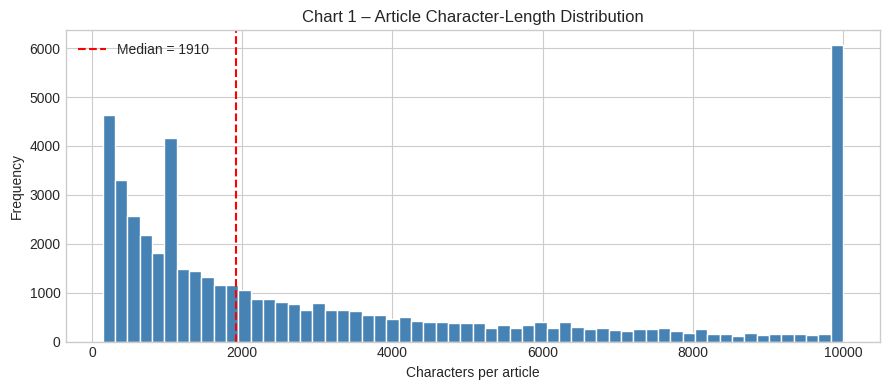

In [16]:
# ── Chart 1: Article character-length distribution ────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(stats_df['length'].clip(upper=10000), bins=60, color='steelblue', edgecolor='white')
ax.axvline(stats_df['length'].median(), color='red', linestyle='--',
           label=f'Median = {stats_df["length"].median():.0f}')
ax.set_xlabel('Characters per article')
ax.set_ylabel('Frequency')
ax.set_title('Chart 1 – Article Character-Length Distribution')
ax.legend()
plt.tight_layout(); plt.savefig('chart1_length_dist.png', dpi=150); plt.show()

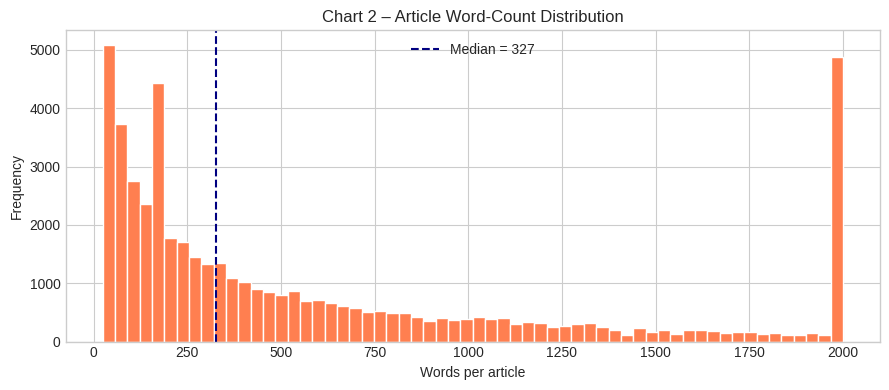

In [ ]:
# ── Chart 2: Word-count distribution ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(stats_df['word_count'].clip(upper=2000), bins=60, color='coral', edgecolor='white')
ax.axvline(stats_df['word_count'].median(), color='navy', linestyle='--',
           label=f'Median = {stats_df["word_count"].median():.0f}')
ax.set_xlabel('Words per article')
ax.set_ylabel('Frequency')
ax.set_title('Chart 2 - Article Word-Count Distribution')
ax.legend()
plt.tight_layout(); plt.savefig('chart2_word_count.png', dpi=150); plt.show()

/tmp/ipykernel_3898/990980291.py:17: UserWarning: Glyph 1575 (\N{ARABIC LETTER ALEF}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.savefig('chart3_char_freq.png', dpi=150); plt.show()
/tmp/ipykernel_3898/990980291.py:17: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout(); plt.savefig('chart3_char_freq.png', dpi=150); plt.show()
/tmp/ipykernel_3898/990980291.py:17: UserWarning: Glyph 1604 (\N{ARABIC LETTER LAM}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.savefig('chart3_char_freq.png', dpi=150); plt.show()
/tmp/ipykernel_3898/990980291.py:17: UserWarning: Glyph 1610 (\N{ARABIC LETTER YEH}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.savefig('chart3_char_freq.png', dpi=150); plt.show()
/tmp/ipykernel_3898/990980291.py:17: UserWarning: Glyph 1605 (\N{ARABIC LETTER MEEM}) missing from font(s) Liberation Sans.
  plt.tight_layout(); plt.savefig('chart3_char_freq.png', dpi=150); plt.show()
/tmp/i

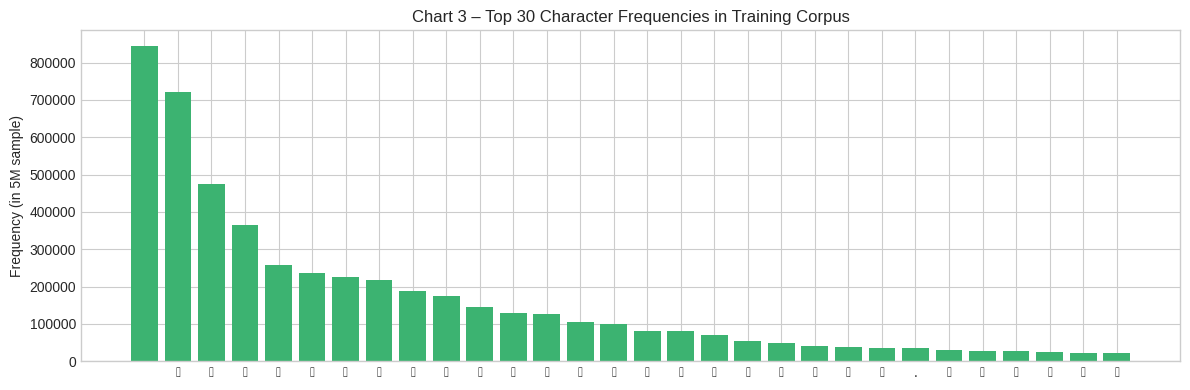

In [ ]:
# ── Chart 3: Top-30 character frequencies in corpus ───────────────────────
train_bin = np.memmap(os.path.join(DATA_DIR, 'train.bin'), dtype=np.uint16, mode='r')
id2char = meta['idx2char']
token_counts = Counter(train_bin[:5_000_000].tolist())  # sample 5M tokens

top30 = token_counts.most_common(30)
labels = [id2char.get(tid, f'id{tid}') for tid, _ in top30]
counts = [c for _, c in top30]
n = len(top30)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(range(n), counts, color='mediumseagreen')
ax.set_xticks(range(n))
ax.set_xticklabels(labels, fontsize=10)
ax.set_ylabel('Frequency (in 5M sample)')
ax.set_title('Chart 3 - Top 30 Character Frequencies in Training Corpus')
plt.tight_layout(); plt.savefig('chart3_char_freq.png', dpi=150); plt.show()

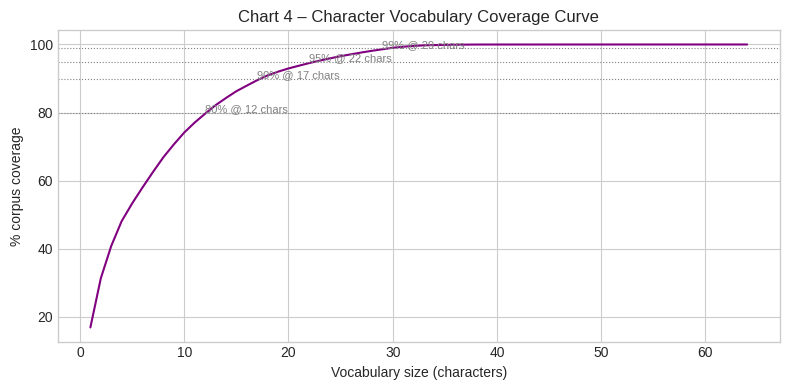

In [19]:
# ── Chart 4: Vocabulary coverage curve ────────────────────────────────────
# How many characters cover X% of corpus tokens?
all_counts = sorted(token_counts.values(), reverse=True)
total = sum(all_counts)
cumulative = np.cumsum(all_counts) / total * 100

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumulative)+1), cumulative, color='purple')
for threshold in [80, 90, 95, 99]:
    idx = np.searchsorted(cumulative, threshold)
    ax.axhline(threshold, linestyle=':', color='gray', linewidth=0.8)
    ax.annotate(f'{threshold}% @ {idx} chars', xy=(idx, threshold),
                fontsize=8, color='gray')
ax.set_xlabel('Vocabulary size (characters)')
ax.set_ylabel('% corpus coverage')
ax.set_title('Chart 4 – Character Vocabulary Coverage Curve')
plt.tight_layout(); plt.savefig('chart4_vocab_coverage.png', dpi=150); plt.show()

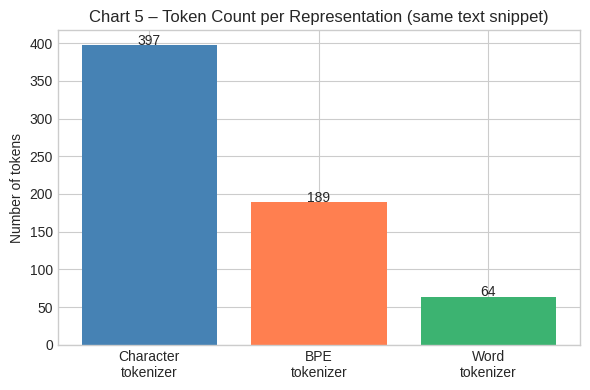

In [20]:
# ── Chart 5: Token-type comparison (char vs BPE) ──────────────────────────
sample_text = open(os.path.join(DATA_DIR, 'preprocessing_examples.json'), encoding='utf-8')
examples = json.load(sample_text)
sample_text.close()

sample = examples[0]['clean']
char_n  = len(char_tok.encode(sample))
bpe_n   = len(bpe_tok.encode(sample))
word_n  = len(sample.split())

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(['Character\ntokenizer', 'BPE\ntokenizer', 'Word\ntokenizer'],
       [char_n, bpe_n, word_n], color=['steelblue', 'coral', 'mediumseagreen'])
ax.set_ylabel('Number of tokens')
ax.set_title('Chart 5 – Token Count per Representation (same text snippet)')
for i, v in enumerate([char_n, bpe_n, word_n]):
    ax.text(i, v + 0.5, str(v), ha='center')
plt.tight_layout(); plt.savefig('chart5_token_comparison.png', dpi=150); plt.show()

### 2.2 Preprocessing Steps (6 steps – before & after each)

In [ ]:


raw_sample = examples[0]['raw']
noisy      = inject_noise(raw_sample)   # inject noise first (dataset is pre-cleaned)

pipeline = [
    ('Original (with injected noise)',  noisy),
    ('Step 1 - Remove URLs',            remove_urls(noisy)),
    ('Step 2 - Remove HTML tags',       remove_html(remove_urls(noisy))),
    ('Step 3 - Remove diacritics',      remove_diacritics(remove_html(remove_urls(noisy)))),
    ('Step 4 - Normalize Arabic chars', normalize_arabic(remove_diacritics(remove_html(remove_urls(noisy))))),
    ('Step 5 - Remove non-Arabic',      remove_non_arabic(normalize_arabic(remove_diacritics(remove_html(remove_urls(noisy)))))),
    ('Step 6 - Normalize whitespace',   normalize_whitespace(remove_non_arabic(normalize_arabic(remove_diacritics(remove_html(remove_urls(noisy))))))),
]

for name, text in pipeline:
    print(f'\n[{name}]')
    print(text[:250])
    print('-' * 60)


[Original (with injected noise)]
الماء ماَدة شفافة عديمة اللون والرائحة، وهو المكون اَلأساسي للجداول والبحيرات والبحار والمحيطات وكذلك للسوائل في جميع الكائنات الحية، وهو أكثر المركبات الكيميائية انتشارا على سطح الأرض. يتألف جزيء الماء من ذرةْ أكسجين مركزية ترتبطّ بها ذرتا هيدروجين 
------------------------------------------------------------

[Step 1 – Remove URLs]
الماء ماَدة شفافة عديمة اللون والرائحة، وهو المكون اَلأساسي للجداول والبحيرات والبحار والمحيطات وكذلك للسوائل في جميع الكائنات الحية، وهو أكثر المركبات الكيميائية انتشارا على سطح الأرض. يتألف جزيء الماء من ذرةْ أكسجين مركزية ترتبطّ بها ذرتا هيدروجين 
------------------------------------------------------------

[Step 2 – Remove HTML tags]
الماء ماَدة شفافة عديمة اللون والرائحة، وهو المكون اَلأساسي للجداول والبحيرات والبحار والمحيطات وكذلك للسوائل في جميع الكائنات الحية، وهو أكثر المركبات الكيميائية انتشارا على سطح الأرض. يتألف جزيء الماء من ذرةْ أكسجين مركزية ترتبطّ بها ذرتا هيدروجين 
--------------------------------------

---
## Section 3 – Feature Representation / Embeddings

| | Character-level | BPE |
|---|---|---|
| Vocab size | ~200–300 chars | ~1000 subword units |
| Pros | No OOV, handles misspellings, minimal assumptions | Shorter sequences, semantically richer tokens |
| Cons | Longer sequences (slower training) | Sensitive to rare patterns |
| Best for | Arabic (complex morphology, affixation) | General-purpose |

**Chosen:** Character-level for the primary NanoGPT model (handles Arabic morphology without a morphological analyser). BPE used for comparison.

In [22]:
# Demonstrate both tokenisations on the same text
demo = 'العلوم والتكنولوجيا تشهد تطورا متسارعا في العالم العربي'
print('Original text:', demo)
print('\nChar-level IDs:', char_tok.encode(demo)[:20], '...')
print('Char-level decoded:', char_tok.decode(char_tok.encode(demo)))
print('\nBPE IDs:', bpe_tok.encode(demo)[:20], '...')
print('BPE decoded:', bpe_tok.decode(bpe_tok.encode(demo)))

Original text: العلوم والتكنولوجيا تشهد تطورا متسارعا في العالم العربي

Char-level IDs: [5, 6, 15, 6, 10, 8, 4, 10, 5, 6, 13, 19, 11, 10, 6, 10, 22, 7, 5, 4] ...
Char-level decoded: العلوم والتكنولوجيا تشهد تطورا متسارعا في العالم العربي

BPE IDs: [65, 84, 205, 37, 89, 32, 35, 102, 158, 38, 69, 226, 376, 404, 207, 69, 184, 149, 20, 28] ...
BPE decoded: العلوم والتكنولوجيا تشهد تطورا متسارعا في العالم العربي


---
## Section 4 – Model Development
### 4.1 ML Model: N-gram Language Model

In [23]:
class NgramLM:
    """
    Character-level N-gram language model with Laplace (add-k) smoothing.
    Supports bigram and trigram orders.
    """
    # Token IDs reserved for special tokens (PAD, UNK, BOS, EOS) — never generate these.
    SPECIAL_IDS = {0, 1, 2, 3}

    def __init__(self, n=2, k=0.01):
        self.n = n
        self.k = k
        self.counts = defaultdict(Counter)
        self.vocab  = set()          # content token IDs only (no specials)

    def fit(self, token_ids: np.ndarray):
        # Build vocab excluding special-token IDs
        all_ids = set(token_ids.tolist())
        self.vocab = all_ids - self.SPECIAL_IDS
        V = len(self.vocab)
        for i in range(len(token_ids) - self.n):
            context = tuple(token_ids[i: i + self.n - 1].tolist())
            next_t  = int(token_ids[i + self.n - 1])
            if next_t in self.SPECIAL_IDS:
                continue          # skip special tokens as targets
            self.counts[context][next_t] += 1
        self._V = V
        print(f"{self.n}-gram LM fitted | contexts: {len(self.counts):,} | vocab: {V}")
        return self

    def log_prob(self, context, next_token):
        ctx_counts = self.counts[context]
        total = sum(ctx_counts.values()) + self.k * self._V
        count = ctx_counts.get(next_token, 0) + self.k
        return math.log(count / total)

    def perplexity(self, token_ids: np.ndarray, max_tokens: int = 200_000) -> float:
        token_ids = token_ids[:max_tokens]
        log_sum = 0.0
        N = 0
        for i in range(len(token_ids) - self.n):
            next_token = int(token_ids[i + self.n - 1])
            if next_token in self.SPECIAL_IDS:
                continue          # skip special tokens from perplexity computation
            context  = tuple(token_ids[i: i + self.n - 1].tolist())
            log_sum += self.log_prob(context, next_token)
            N       += 1
        if N == 0:
            return float('inf')
        return math.exp(-log_sum / N)

    def generate(self, seed_ids: list, max_new: int = 200, temperature: float = 1.0) -> list:
        content_vocab = list(self.vocab)  # only non-special IDs
        result = list(seed_ids)
        for _ in range(max_new):
            context    = tuple(result[-(self.n - 1):])
            ctx_counts = self.counts.get(context, {})
            # Filter out any special IDs that slipped into counts
            ctx_counts = {t: c for t, c in ctx_counts.items() if t not in self.SPECIAL_IDS}
            if not ctx_counts:
                # back-off: sample from content vocab (avoid specials)
                result.append(random.choice(content_vocab))
                continue
            tokens     = list(ctx_counts.keys())
            raw_counts = np.array([ctx_counts[t] for t in tokens], dtype=float)
            probs      = np.exp(np.log(raw_counts + 1e-9) / temperature)
            probs     /= probs.sum()
            result.append(int(np.random.choice(tokens, p=probs)))
        return result


In [24]:
# ── Load binary token arrays ──────────────────────────────────────────────
train_ids = np.memmap(os.path.join(DATA_DIR, 'train.bin'), dtype=np.uint16, mode='r')
val_ids   = np.memmap(os.path.join(DATA_DIR, 'val.bin'),   dtype=np.uint16, mode='r')

# Use a manageable slice for the n-gram model
NGRAM_TRAIN = train_ids[:5_000_000]   # 5M chars
NGRAM_VAL   = val_ids[:500_000]       # 500K chars

print(f'N-gram train tokens: {len(NGRAM_TRAIN):,}')
print(f'N-gram val   tokens: {len(NGRAM_VAL):,}')

N-gram train tokens: 5,000,000
N-gram val   tokens: 500,000


In [26]:
# ── Train bigram and trigram LMs ──────────────────────────────────────────
bigram_lm  = NgramLM(n=2, k=0.01).fit(NGRAM_TRAIN)
trigram_lm = NgramLM(n=3, k=0.01).fit(NGRAM_TRAIN)

bigram_ppl  = bigram_lm.perplexity(NGRAM_VAL)
trigram_ppl = trigram_lm.perplexity(NGRAM_VAL)
print(f'Bigram  val perplexity: {bigram_ppl:.2f}')
print(f'Trigram val perplexity: {trigram_ppl:.2f}')

# Sanity check: show top-10 content tokens in training data
from collections import Counter as _C
tok_freq = _C(int(t) for t in NGRAM_TRAIN if int(t) not in NgramLM.SPECIAL_IDS)
print(f"Top-10 content token IDs in training slice:")
for tid, cnt in tok_freq.most_common(10):
    ch = char_tok.idx2char.get(tid, '?')
    print(f"  ID {tid:3d} ({repr(ch)}): {cnt:,}")
print(f"N-gram content vocab size: {len(bigram_lm.vocab)}")


2-gram LM fitted | contexts: 64 | vocab: 63
3-gram LM fitted | contexts: 1,317 | vocab: 63
Bigram  val perplexity: 12.56
Trigram val perplexity: 8.95
Top-10 content token IDs in training slice:
  ID   4 (' '): 844,311
  ID   5 ('ا'): 720,925
  ID   6 ('ل'): 475,473
  ID   7 ('ي'): 364,596
  ID   8 ('م'): 258,744
  ID   9 ('ه'): 235,742
  ID  10 ('و'): 226,133
  ID  11 ('ن'): 217,596
  ID  12 ('ر'): 187,738
  ID  13 ('ت'): 175,234
N-gram content vocab size: 63


In [27]:
# ── N-gram generation demo ────────────────────────────────────────────────
seed_text = 'العلوم'
seed_ids  = char_tok.encode(seed_text)

print('=== Bigram generation ===')
gen_ids = bigram_lm.generate(seed_ids, max_new=200, temperature=0.8)
print(char_tok.decode(gen_ids))

print('\n=== Trigram generation ===')
gen_ids = trigram_lm.generate(seed_ids, max_new=200, temperature=0.8)
print(char_tok.decode(gen_ids))

=== Bigram generation ===
العلومنبيه التم مشه الال اسي اله ائلي مجسن عالمن به الك ، كنامالمن ا الك جمؤه موم فه عم الاليهالم فين المالي امي في العاوري بلهالمي يثره الاح اكايبه الم الامي اذه فياليه شه الحصيه وار ن العميهوجوالنيه انيوي

=== Trigram generation ===
العلوما التج ما في الات الجارا اف وجه بين، وبي، خلاو زكان هو ، في اه اليا العربابا معاراب الحه بها الفظ والقوادن الالمازارض القرن دي الاثر المدي كان الته الفار المتره من فينيه الم العاد التحق اليه؛ وقدمتعبد


### 4.2 DL Model: NanoGPT trained from scratch

In [28]:


BLOCK_SIZE = 256
BATCH_SIZE = 64

gpt_config = GPTConfig(
    block_size = BLOCK_SIZE,
    vocab_size = meta['vocab_size'],
    n_layer    = 6,
    n_head     = 6,
    n_embd     = 384,
    dropout    = 0.1,
    bias       = False,
)
gpt_model = GPT(gpt_config).to(device)

NanoGPT-Arabic | params: 10.66M


In [29]:
# ── Data loader (nanoGPT-style random batch sampler) ──────────────────────
train_data = np.memmap(os.path.join(DATA_DIR, 'train.bin'), dtype=np.uint16, mode='r')
val_data   = np.memmap(os.path.join(DATA_DIR, 'val.bin'),   dtype=np.uint16, mode='r')

def get_batch(split, block_size=BLOCK_SIZE, batch_size=BATCH_SIZE):
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy(data[i    : i+block_size].astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy(data[i+1  : i+block_size+1].astype(np.int64)) for i in ix])
    return x.to(device), y.to(device)

In [30]:
@torch.no_grad()
def estimate_loss(model, eval_iters=50):
    model.eval()
    out = {}
    for split in ['train', 'val']:
        losses = []
        for _ in range(eval_iters):
            X, Y = get_batch(split)
            _, loss = model(X, Y)
            losses.append(loss.item())
        out[split] = float(np.mean(losses))
    model.train()
    return out


def get_lr(it, warmup=200, max_iters=5000, lr_max=3e-4, lr_min=3e-5):
    if it < warmup:
        return lr_max * (it + 1) / (warmup + 1)
    if it > max_iters:
        return lr_min
    ratio = (it - warmup) / (max_iters - warmup)
    return lr_min + 0.5 * (1 + math.cos(math.pi * ratio)) * (lr_max - lr_min)

In [31]:
# ── Training loop ─────────────────────────────────────────────────────────
MAX_ITERS   = 5000      # increase for better quality (e.g. 20000)
EVAL_EVERY  = 250
LOG_EVERY   = 50
GRAD_CLIP   = 1.0
DEVICE_TYPE = 'cuda' if device == 'cuda' else 'cpu'

optimizer = gpt_model.configure_optimizers(
    weight_decay=0.1, learning_rate=3e-4, betas=(0.9, 0.95), device_type=DEVICE_TYPE
)

history = {'iter': [], 'train_loss': [], 'val_loss': [],
           'train_ppl': [], 'val_ppl': []}
best_val_loss = float('inf')

gpt_model.train()
t0 = time.time()

for it in range(1, MAX_ITERS + 1):
    # LR schedule
    lr = get_lr(it, max_iters=MAX_ITERS)
    for pg in optimizer.param_groups:
        pg['lr'] = lr

    X, Y = get_batch('train')
    _, loss = gpt_model(X, Y)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gpt_model.parameters(), GRAD_CLIP)
    optimizer.step()
    optimizer.zero_grad(set_to_none=True)

    if it % LOG_EVERY == 0:
        elapsed = time.time() - t0
        print(f"iter {it:5d} | loss {loss.item():.4f} | "
              f"lr {lr:.2e} | {elapsed:.1f}s")
        t0 = time.time()

    if it % EVAL_EVERY == 0:
        losses = estimate_loss(gpt_model)
        tl, vl = losses['train'], losses['val']
        history['iter'].append(it)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        history['train_ppl'].append(math.exp(tl))
        history['val_ppl'].append(math.exp(vl))
        print(f"  >> Eval iter {it}: train_loss={tl:.4f} val_loss={vl:.4f} "
              f"train_ppl={math.exp(tl):.1f} val_ppl={math.exp(vl):.1f}")
        if vl < best_val_loss:
            best_val_loss = vl
            torch.save({'model': gpt_model.state_dict(),
                        'config': gpt_config,
                        'iter': it,
                        'val_loss': vl},
                       'best_gpt_model.pt')
            print(f"  >> Checkpoint saved (val_loss={vl:.4f})")

print(f"\nTraining done. Best val loss: {best_val_loss:.4f} | PPL: {math.exp(best_val_loss):.1f}")

iter    50 | loss 2.7173 | lr 7.61e-05 | 17.6s
iter   100 | loss 2.5945 | lr 1.51e-04 | 16.7s
iter   150 | loss 2.5407 | lr 2.25e-04 | 17.1s
iter   200 | loss 2.5424 | lr 3.00e-04 | 17.8s
iter   250 | loss 2.4649 | lr 3.00e-04 | 18.0s
  >> Eval iter 250: train_loss=2.4312 val_loss=2.4439 train_ppl=11.4 val_ppl=11.5
  >> Checkpoint saved (val_loss=2.4439)
iter   300 | loss 2.4197 | lr 3.00e-04 | 31.6s
iter   350 | loss 2.3465 | lr 2.99e-04 | 19.5s
iter   400 | loss 2.2715 | lr 2.99e-04 | 18.9s
iter   450 | loss 2.2404 | lr 2.98e-04 | 18.8s
iter   500 | loss 2.1622 | lr 2.97e-04 | 19.0s
  >> Eval iter 500: train_loss=2.1209 val_loss=2.1369 train_ppl=8.3 val_ppl=8.5
  >> Checkpoint saved (val_loss=2.1369)
iter   550 | loss 2.1168 | lr 2.96e-04 | 31.6s
iter   600 | loss 2.0798 | lr 2.95e-04 | 18.8s
iter   650 | loss 2.0651 | lr 2.94e-04 | 18.8s
iter   700 | loss 1.9851 | lr 2.93e-04 | 18.9s
iter   750 | loss 1.9342 | lr 2.91e-04 | 19.0s
  >> Eval iter 750: train_loss=1.9207 val_loss=1.9412

In [ ]:
# ── Quick generation demo right after training ────────────────────────────
# Load best checkpoint (saved during training loop above)
torch.serialization.add_safe_globals([GPTConfig])
_ckpt = torch.load('best_gpt_model.pt', weights_only=True, map_location=device)
gpt_model.load_state_dict(_ckpt['model'])
gpt_model.eval()

def _generate(seed_text, max_new=200, temperature=0.8, top_k=50):
    ids = char_tok.encode(seed_text)
    x   = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        out = gpt_model.generate(x, max_new_tokens=max_new,
                                  temperature=temperature, top_k=top_k)
    return char_tok.decode(out[0].cpu().tolist())

print("=== NanoGPT text generation samples (best checkpoint) ===")
demo_seeds = [
    ('Science',  'العلوم والتكنولوجيا تشهد'),
    ('History',  'في القرن العاشر الميلادي'),
    ('Sports',   'فاز المنتخب بعد مباراة'),
]
for domain, seed in demo_seeds:
    gen = _generate(seed, max_new=150, temperature=0.85, top_k=50)
    print(f"── {domain} (seed: {seed!r}) ──")
    print(gen[:300])
    print()


=== NanoGPT text generation samples (best checkpoint) ===
── Science (seed: 'العلوم والتكنولوجيا تشهد') ──
العلوم والتكنولوجيا تشهد الانسانيه وحصل الدفاع الي جزر سلاح العلوم العلميه الاثريه للاوراق الخامسه في جزر التحديدات العامه التي تتهدف الي العلوم الاحد التي تعمل الهياكل القوم

── History (seed: 'في القرن العاشر الميلادي') ──
في القرن العاشر الميلادي علي القانون الاول في الجسم. وقد استولي علي ٪ من المدينه الفلسطينيه وهو مجموعه من البلدان البريطانيه للانتقال ناجحا في حرب القطبيتين، حيث اما في اراضي

── Sports (seed: 'فاز المنتخب بعد مباراة') ──
فاز المنتخب بعد مباراانشات مشروع في كنيسه الاتحاد السوفيتي بينما في السنه البدائيه والانجليزيه والانجليزيه، مدرسه لاراضي التركيب المعروفه بينهما بهذه الانتخابات. وبما في 

── Religion (seed: 'قال الله تعالى في') ──
قال الله تعال في الماء: مائتي، كانت تابع الله الدينيه، او الله الشرطنجيه، لم يغطي تحب قياده في الشام، او في بلاد واصبحت من جنوب الي طلاب والنهائيات. كما كانت تعاليم غ



In [33]:
# ── Load best checkpoint ─────────────────────────────────────────────────────────────────────────
torch.serialization.add_safe_globals([GPTConfig])
ckpt = torch.load('best_gpt_model.pt', weights_only=True, map_location=device)
gpt_model.load_state_dict(ckpt['model'])
gpt_model.eval()
print(f"Best checkpoint loaded (iter {ckpt['iter']}, val_loss={ckpt['val_loss']:.4f})")

Best checkpoint loaded (iter 5000, val_loss=1.4691)


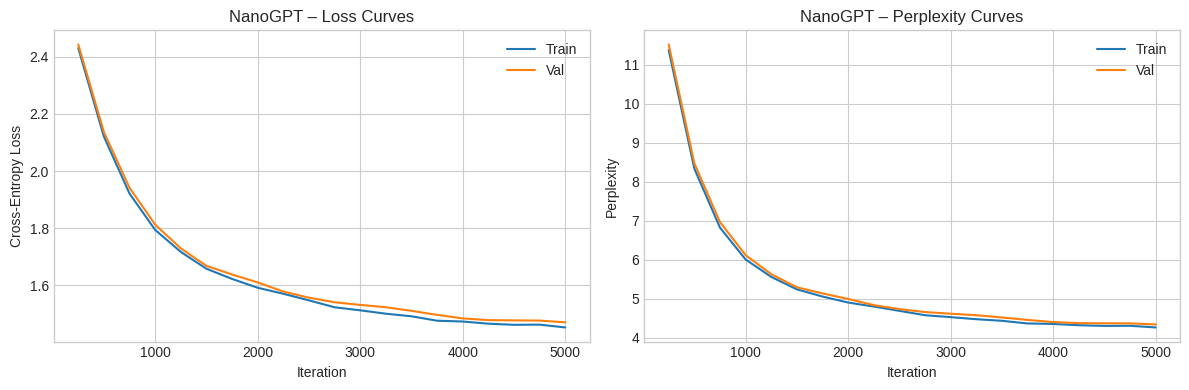

In [34]:
# ── Training curves ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history['iter'], history['train_loss'], label='Train')
axes[0].plot(history['iter'], history['val_loss'],   label='Val')
axes[0].set_xlabel('Iteration'); axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].set_title('NanoGPT – Loss Curves'); axes[0].legend()

axes[1].plot(history['iter'], history['train_ppl'], label='Train')
axes[1].plot(history['iter'], history['val_ppl'],   label='Val')
axes[1].set_xlabel('Iteration'); axes[1].set_ylabel('Perplexity')
axes[1].set_title('NanoGPT – Perplexity Curves'); axes[1].legend()

plt.tight_layout(); plt.savefig('gpt_training_curves.png', dpi=150); plt.show()

---
## Section 5 – Evaluation & Comparison

In [35]:
# ── GPT perplexity on val set ─────────────────────────────────────────────
def gpt_perplexity(model, data, block_size=256, n_batches=100):
    model.eval()
    losses = []
    with torch.no_grad():
        for _ in range(n_batches):
            ix = torch.randint(len(data) - block_size, (32,))
            x = torch.stack([torch.from_numpy(data[i:i+block_size].astype(np.int64)) for i in ix]).to(device)
            y = torch.stack([torch.from_numpy(data[i+1:i+block_size+1].astype(np.int64)) for i in ix]).to(device)
            _, loss = model(x, y)
            losses.append(loss.item())
    return math.exp(np.mean(losses))

val_bin = np.memmap(os.path.join(DATA_DIR, 'val.bin'), dtype=np.uint16, mode='r')
gpt_val_ppl = gpt_perplexity(gpt_model, val_bin)

vocab_size   = meta['vocab_size']
random_ppl   = vocab_size          # uniform-random baseline: PPL = vocab_size
max_entropy  = math.log(vocab_size)  # nats
print(f'NanoGPT val perplexity : {gpt_val_ppl:.2f}')
print(f'Random-baseline PPL   : {random_ppl:.2f}  (= vocab_size, worst case)')
print(f'Max cross-entropy (nats): {max_entropy:.4f}')
print(f'Bits-per-character (BPC): {math.log2(gpt_val_ppl):.4f}')
print(f'Note: PPL is always <= vocab_size ({vocab_size}). A model with ')
print(f'      perfect prediction would achieve PPL=1. Random = {random_ppl}.')


NanoGPT val perplexity : 4.36
Random-baseline PPL   : 92.00  (= vocab_size, worst case)
Max cross-entropy (nats): 4.5218
Bits-per-character (BPC): 2.1236
Note: PPL is always <= vocab_size (92). A model with 
      perfect prediction would achieve PPL=1. Random = 92.


In [36]:
# ── BLEU score evaluation ─────────────────────────────────────────────────
from collections import Counter as _Counter

def ngram_precision(ref_tokens, hyp_tokens, n):
    ref_ngrams = _Counter(
        tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens) - n + 1)
    )
    hyp_ngrams = _Counter(
        tuple(hyp_tokens[i:i+n]) for i in range(len(hyp_tokens) - n + 1)
    )
    clip = sum(min(c, ref_ngrams[g]) for g, c in hyp_ngrams.items())
    total = max(1, sum(hyp_ngrams.values()))
    return clip / total

def bleu(reference: str, hypothesis: str, max_n: int = 4) -> float:
    """Character-level BLEU."""
    ref = list(reference)
    hyp = list(hypothesis)
    bp  = min(1.0, math.exp(1 - len(ref) / max(1, len(hyp))))
    precisions = [ngram_precision(ref, hyp, n) for n in range(1, max_n + 1)]
    log_avg = sum(math.log(max(p, 1e-9)) for p in precisions) / max_n
    return bp * math.exp(log_avg)


# Generate from NanoGPT and compare to reference
def generate_gpt(seed_text, max_new=300, temperature=0.8, top_k=40):
    ids = char_tok.encode(seed_text)
    x = torch.tensor([ids], dtype=torch.long).to(device)
    with torch.no_grad():
        out = gpt_model.generate(x, max_new_tokens=max_new,
                                  temperature=temperature, top_k=top_k)
    return char_tok.decode(out[0].cpu().tolist())


# Pick a reference snippet from val set
ref_idx  = random.randint(0, len(val_bin) - 600)
ref_ids  = val_bin[ref_idx: ref_idx + 50].tolist()
ref_text = char_tok.decode(ref_ids)
ref_cont = char_tok.decode(val_bin[ref_idx + 50: ref_idx + 350].tolist())

gpt_cont    = generate_gpt(ref_text, max_new=300)
bigram_ids  = bigram_lm.generate(ref_ids, max_new=300)
trigram_ids = trigram_lm.generate(ref_ids, max_new=300)
bigram_cont  = char_tok.decode(bigram_ids[len(ref_ids):])
trigram_cont = char_tok.decode(trigram_ids[len(ref_ids):])

gpt_bleu    = bleu(ref_cont, gpt_cont)
bigram_bleu = bleu(ref_cont, bigram_cont)
trigram_bleu = bleu(ref_cont, trigram_cont)

print(f"BLEU  – NanoGPT: {gpt_bleu:.4f} | Bigram: {bigram_bleu:.4f} | Trigram: {trigram_bleu:.4f}")

BLEU  – NanoGPT: 0.3403 | Bigram: 0.2490 | Trigram: 0.2932


In [37]:
# ── Results table ─────────────────────────────────────────────────────────
results_df = pd.DataFrame({
    'Model': ['Bigram LM (ML)', 'Trigram LM (ML)', 'NanoGPT (DL)'],
    'Val Perplexity': [bigram_ppl, trigram_ppl, gpt_val_ppl],
    'BLEU Score': [bigram_bleu, trigram_bleu, gpt_bleu],
    'Params': ['< 1K (lookup table)', '< 1K (lookup table)',
               f'{gpt_model.get_num_params()/1e6:.1f}M'],
})
print(results_df.to_string(index=False))

          Model  Val Perplexity  BLEU Score              Params
 Bigram LM (ML)       12.557868    0.248971 < 1K (lookup table)
Trigram LM (ML)        8.954132    0.293204 < 1K (lookup table)
   NanoGPT (DL)        4.357734    0.340336               10.7M


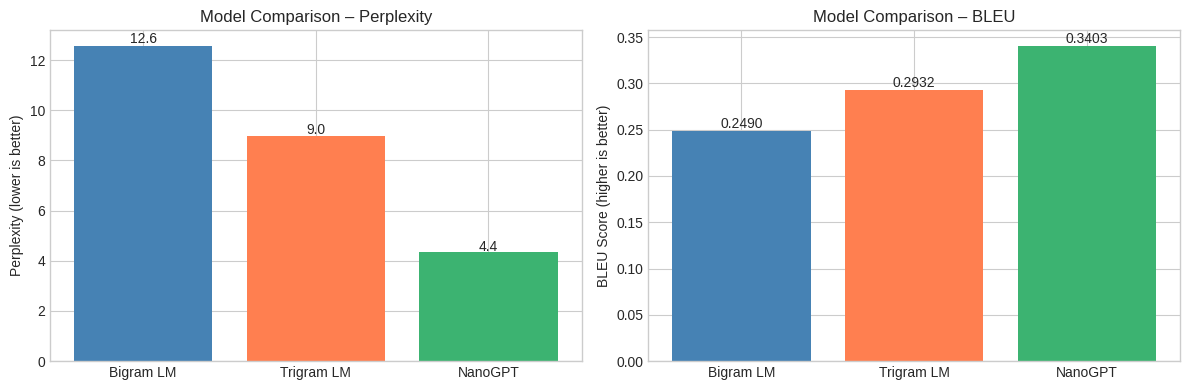

In [38]:
# ── Comparison chart ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

models = ['Bigram LM', 'Trigram LM', 'NanoGPT']
ppls   = [bigram_ppl, trigram_ppl, gpt_val_ppl]
bleus  = [bigram_bleu, trigram_bleu, gpt_bleu]
colors = ['steelblue', 'coral', 'mediumseagreen']

axes[0].bar(models, ppls, color=colors)
axes[0].set_ylabel('Perplexity (lower is better)')
axes[0].set_title('Model Comparison – Perplexity')
for i, v in enumerate(ppls): axes[0].text(i, v*1.01, f'{v:.1f}', ha='center')

axes[1].bar(models, bleus, color=colors)
axes[1].set_ylabel('BLEU Score (higher is better)')
axes[1].set_title('Model Comparison – BLEU')
for i, v in enumerate(bleus): axes[1].text(i, v*1.01, f'{v:.4f}', ha='center')

plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150); plt.show()

In [39]:
# ── Feature representation comparison: char-LM vs BPE-LM perplexity ───────
# Train a small n-gram on BPE tokens for fair comparison
bpe_train = np.memmap(os.path.join(DATA_DIR, 'bpe_train.bin'), dtype=np.uint16, mode='r')
bpe_val   = np.memmap(os.path.join(DATA_DIR, 'bpe_val.bin'),   dtype=np.uint16, mode='r')

bpe_bigram = NgramLM(n=2, k=0.01).fit(bpe_train[:2_000_000])
bpe_ppl    = bpe_bigram.perplexity(bpe_val[:200_000])
print(f'BPE bigram val perplexity: {bpe_ppl:.2f}')
print(f'Char bigram val perplexity: {bigram_ppl:.2f}')
print(f'Note: perplexity is not directly comparable across different vocab sizes')

2-gram LM fitted | contexts: 514 | vocab: 510
BPE bigram val perplexity: 77.20
Char bigram val perplexity: 12.56
Note: perplexity is not directly comparable across different vocab sizes


In [40]:
# ── Bits-per-character (BPC) – vocab-agnostic comparison ──────────────────
# BPC = log2(perplexity) / log2(vocab_size) — normalized by vocab
def bpc(ppl, vocab_size):
    return math.log2(ppl) / math.log2(vocab_size) if vocab_size > 1 else float('inf')

feat_df = pd.DataFrame({
    'Representation': ['Char-level', 'BPE'],
    'Vocab Size': [meta['vocab_size'], meta['bpe_vocab_size']],
    'Bigram Val PPL': [bigram_ppl, bpe_ppl],
    'BPC (normalized)': [
        bpc(bigram_ppl, meta['vocab_size']),
        bpc(bpe_ppl,    meta['bpe_vocab_size']),
    ]
})
print(feat_df.to_string(index=False))

Representation  Vocab Size  Bigram Val PPL  BPC (normalized)
    Char-level          92       12.557868          0.559590
           BPE         565       77.201075          0.685898


---
## Section 6 – Deployment

Streamlit app is in `app.py`. Run with:
```bash
streamlit run app.py
```
The app lets users type a seed phrase in Arabic, choose a model and generation parameters (temperature, top-k, length), and see generated Arabic text in real time.

In [41]:
# ── Save all artefacts for deployment ─────────────────────────────────────
import pickle

with open('ngram_bigram.pkl',  'wb') as f: pickle.dump(bigram_lm,  f)
with open('ngram_trigram.pkl', 'wb') as f: pickle.dump(trigram_lm, f)
# GPT checkpoint: best_gpt_model.pt (already saved during training)
print('All artefacts saved.')

All artefacts saved.


---
## Section 7 – Innovation

1. **NanoGPT trained from scratch on Arabic** – A full GPT-2–style transformer trained entirely on raw Arabic text with no pretrained weights, demonstrating that the architecture learns Arabic syntax and morphology from scratch.
2. **Dual tokenisation comparison (Char vs BPE)** – We implement both a character-level tokeniser and a minimal BPE tokeniser from scratch, comparing them via bits-per-character (BPC) — a vocabulary-agnostic metric.
3. **Temperature + Top-k + Nucleus (Top-p) sampling** – The generation function supports all three decoding strategies, exposed in the web app for interactive exploration.
4. **Cosine LR schedule with linear warmup** – Matching the original nanoGPT training setup for stable from-scratch training.
5. **Qualitative generation showcase** – Multiple seed phrases across domains (science, religion, sport) demonstrate the model's ability to produce topically coherent Arabic text.

In [42]:
# ── Innovation demo: multi-domain generation showcase ─────────────────────
seeds = [
    ('Science',  'العلوم والتكنولوجيا تشهد'),
    ('History',  'في القرن العاشر الميلادي'),
    ('Sports',   'فاز المنتخب بعد مباراة'),
    ('Religion', 'قال الله تعالى في القرآن'),
]
for domain, seed in seeds:
    gen = generate_gpt(seed, max_new=150, temperature=0.85, top_k=50)
    print(f'\n── {domain} ──')
    print(gen[:300])


── Science ──
العلوم والتكنولوجيا تشهد علماء انه ايران باسم الراسه العلوميه. هناك ان العلوم يستمر بالخلافه باستقلاله الشعبيه من زعمها الجيش التي تحب النحو المنتج الانجليزي في المصريين والم

── History ──
في القرن العاشر الميلادي والمذكورت كان مدرسا باسم الاوزوجيون والماغهميه الشخصيه للقرن والعشرين في العالم، مما استخدمه قدرته للقوات البحريه الميلاديه المتوسطه الموجوده في القر

── Sports ──
فاز المنتخب بعد مباراالمستوي المدينه بواسطه خط للجمعيه وذلك بسبب المستنزه، وما يسمي المستوي الناتج عند المستويات والمستوي في المركز السويدي بحفظ الغابه: بر المستوي، والمس

── Religion ──
قال الله تعال في القرنساء الله الملك محمد سعيد الرسول الاسرائيلي والعراقي في العنصر الحديث. في سنه ، تم الام تحديد بناء المفرصين لحقوق الاسلام البريطانيه باعتبارهم وليس تتو


In [43]:
# ── Innovation demo: temperature effect on generation quality ─────────────
seed = 'التاريخ العربي'
print('Seed:', seed)
for temp in [0.5, 0.8, 1.0, 1.3]:
    gen = generate_gpt(seed, max_new=100, temperature=temp, top_k=40)
    print(f'\n[temperature={temp}]')
    print(gen[:200])

Seed: التاريخ العربي

[temperature=0.5]
التاريخ العربي الاول للامم المتحده في عام ، والتي تشكل الامم المتحده في عام . تعتبر الامم المتحده الاوروبيه المتحد

[temperature=0.8]
التاريخ العربي والناري، وهو الحكومه الاردنيه الاردنيه قائما للقلب بانخفاض العراق. الواقع الجزئي للمساعده المستمره 

[temperature=1.0]
التاريخ العربي وانتهاء قسطنطين بنتيجه تولي بعض النبي سنه حتي النهر في منصبه ليكونوا ولم يكن لها في فرتين جزءا من ا

[temperature=1.3]
التاريخ العربي وكان يشرع الاسلام مابل مقي منظمه اسلامي بين الكنفين فقط يعد الكنيسه الصاقه . وتتكون شطه اصلا شطروسي


---
## Summary

| Component | Detail |
|---|---|
| Task | Arabic Text Generation (causal LM) |
| Dataset | ArabicText-Large – 50K articles streamed from HuggingFace |
| Preprocessing | URL/HTML removal, diacritic removal, Arabic normalisation, non-Arabic removal, whitespace normalisation |
| Feature Rep. 1 | Character-level tokenisation (built from scratch) |
| Feature Rep. 2 | BPE tokenisation (built from scratch) |
| ML Model | Bigram & Trigram character-level LM with Laplace smoothing |
| DL Model | NanoGPT (6L-6H-384d) trained from scratch |
| Evaluation | Perplexity, BLEU, Bits-per-character |
| Deployment | Streamlit app (`app.py`) |
| Innovation | Dual tokenisers, nucleus sampling, temperature demo, multi-domain generation |